In [35]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/home/shamitr/Projects/ProdAnal_Projects/Telco Churn & Retention Analysis/data/Telcom_Dataset.csv')

In [36]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
df = df.dropna()


##### Percentage of churned users

In [37]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64

73% users are still there, 26% users have churned. This is a good sign for the company as majority of the customers are still with them.

In [43]:
# Contract Type
df["ChurnFlag"] = df["Churn"].map({"Yes": 1, "No": 0})

In [44]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0,10,20,30,40,50,60,70],
)

df.groupby("tenure_group")["ChurnFlag"].mean()

tenure_group
(0, 10]     0.494130
(10, 20]    0.311674
(20, 30]    0.228047
(30, 40]    0.218605
(40, 50]    0.176380
(50, 60]    0.136103
(60, 70]    0.092571
Name: ChurnFlag, dtype: float64

In [45]:
df["tenure_group"].value_counts(normalize=True)

tenure_group
(0, 10]     0.301385
(10, 20]    0.139692
(60, 70]    0.134615
(20, 30]    0.117385
(50, 60]    0.107385
(40, 50]    0.100308
(30, 40]    0.099231
Name: proportion, dtype: float64

#### User Proportions
The above measure shows that majority of the dataset is new customers. Part of the reason why the churn is higher in the early times because of the fact that users are way more in earlier times

In [25]:
# Contract Type means
print(df.groupby("Contract")["ChurnFlag"].mean())
print(" ")

# Internet Service 
print(df.groupby("InternetService")["ChurnFlag"].mean())
print(" ")

# Payment Method
print(df.groupby("PaymentMethod")["ChurnFlag"].mean())
print(" ")


Contract
Month-to-month    0.427097
One year          0.112772
Two year          0.028487
Name: ChurnFlag, dtype: float64
 
InternetService
DSL            0.189983
Fiber optic    0.418928
No             0.074342
Name: ChurnFlag, dtype: float64
 
PaymentMethod
Bank transfer (automatic)    0.167315
Credit card (automatic)      0.152531
Electronic check             0.452854
Mailed check                 0.192020
Name: ChurnFlag, dtype: float64
 


Churn Level variations over different levels of data

#### Contract
Month to month contracts have 42% churn
One year Long contracts have 11% churn
Two year long contracts have 2.8% churn

#### Internet Service
Users with DSL as their internet service provider had 18% churn
Users with Fiber optic internet service providers had 41% churn
Users with no Internet Service provider had 7.4% churn

#### Payment Method
Users that did automatic bank transactions had 16% churn
Users that did automatic Credit Card transactions had 15% churn
Users that did Electronic Check transactions had 45% churn
Users that did Mailed Check transactions had 19% churn

In [26]:
# Insights on Monthly charges
print(df.groupby("Churn")["MonthlyCharges"].mean())
print(" ")
print("Total Monthly Charge for Customers who have Churned: ", df[df["Churn"] == "Yes"]["MonthlyCharges"].sum())

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64
 
Total Monthly Charge for Customers who have Churned:  139130.85


 ### Tenure vs Monthly Charges ScatterPlot 

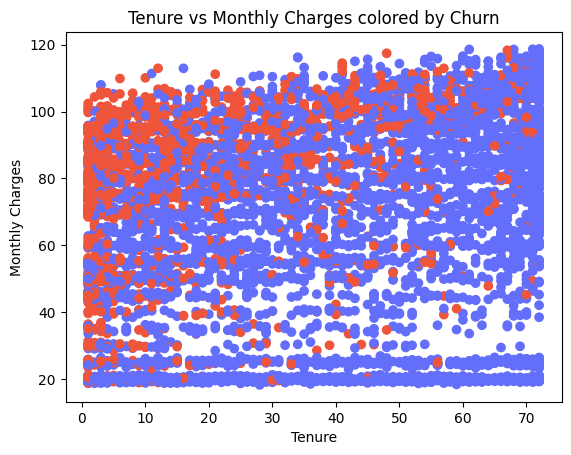

In [29]:
colors = df["ChurnFlag"].map({0: "#636EFA", 1: "#EF553B"})
plt.scatter(df["tenure"], df["MonthlyCharges"], c=colors)
plt.xlabel("Tenure")
plt.ylabel("Monthly Charges")
plt.title("Tenure vs Monthly Charges colored by Churn")
plt.show()

Churn is fairly higher in the earlier months because of early life churn. Customers that have weak commitments, have higher expectations, no habit and are trying a new product which have been led by the hype. They also face onboarding issues because of which the churn is quite high.

However Later down the line, the customers become more loyal and develop habits and take longer term subscriptions like year long ones.
This causes the churn to be significantly lesser towards th end.

In [30]:
services = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]

for col in services:
    print(col)
    print(" ")
    print(df.groupby(col)["ChurnFlag"].mean())
    print(" ")
    

OnlineSecurity
 
OnlineSecurity
No                     0.417787
No internet service    0.074342
Yes                    0.146402
Name: ChurnFlag, dtype: float64
 
OnlineBackup
 
OnlineBackup
No                     0.399417
No internet service    0.074342
Yes                    0.215670
Name: ChurnFlag, dtype: float64
 
DeviceProtection
 
DeviceProtection
No                     0.391403
No internet service    0.074342
Yes                    0.225393
Name: ChurnFlag, dtype: float64
 
TechSupport
 
TechSupport
No                     0.416475
No internet service    0.074342
Yes                    0.151961
Name: ChurnFlag, dtype: float64
 
StreamingTV
 
StreamingTV
No                     0.335351
No internet service    0.074342
Yes                    0.301147
Name: ChurnFlag, dtype: float64
 
StreamingMovies
 
StreamingMovies
No                     0.337289
No internet service    0.074342
Yes                    0.299524
Name: ChurnFlag, dtype: float64
 


In [31]:
from sklearn.preprocessing import StandardScaler

features = df[["tenure", "MonthlyCharges", "TotalCharges"]]

scaler = StandardScaler()
scaled = scaler.fit_transform(features)